In [3]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 66.1 MB/s eta 0:00:00


In [4]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [2]:
# import pickle

# # Open the file in binary read mode
# with open('churn_model.pkl', 'rb') as file:
#     data = pickle.load(file)

# # View the contents of the file
# print(type(data))
# print(data)

In [5]:
st.set_page_config(page_title="Customer Churn Dashboard", layout="wide")



2026-09-20 01:45:38.948 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [9]:
#Loading the model
#model=joblib.load("churn_model.pkl'")
BASE_DIR = os.getcwd()
model_path = os.path.join(BASE_DIR, "churn_model.pkl")

model = joblib.load(model_path)

#Load dataset at once
df=pd.read_csv("European_Bank.csv")

In [10]:
# ---------------- DASHBOARD FILTERS ----------------
st.sidebar.header("📌 Course Configuration")

selected_geo = st.sidebar.selectbox(
    "Select Geography",
    ["All"] + list(df["Geography"].unique())
)

2026-09-20 01:54:17.583 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:54:17.870 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-20 01:54:17.871 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:54:17.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:54:17.876 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:54:17.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:54:17.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:54:17.880 Session state does not 

In [11]:
age_filter = st.sidebar.slider(
    "Select Age Range",
    int(df["Age"].min()),
    int(df["Age"].max()),
    (18, 60)
)

active_only = st.sidebar.checkbox("Active Members Only")

2026-09-20 01:56:47.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:56:47.059 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:56:47.066 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:56:47.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:56:47.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:56:47.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:56:47.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:56:47.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [12]:
product_filter = st.sidebar.slider(
    "Number of Products",
    int(df["NumOfProducts"].min()),
    int(df["NumOfProducts"].max()),
    (1,4)
)

2026-09-20 01:57:52.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:57:52.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:57:52.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:57:52.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:57:52.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [13]:
balance_filter = st.sidebar.slider(
    "Balance Range",
    int(df["Balance"].min()),
    int(df["Balance"].max()),
    (0,200000)
)

2026-09-20 01:58:05.370 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:58:05.371 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:58:05.372 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:58:05.373 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:58:05.374 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [14]:
salary_filter = st.sidebar.slider(
    "Salary Range",
    int(df["EstimatedSalary"].min()),
    int(df["EstimatedSalary"].max()),
    (0,200000)
)

2026-09-20 01:58:15.973 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:58:15.976 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:58:15.977 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:58:15.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 01:58:15.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [15]:
filtered_df = df.copy()

if selected_geo != "All":
    filtered_df = filtered_df[filtered_df["Geography"] == selected_geo]

filtered_df = filtered_df[
    (filtered_df["Age"] >= age_filter[0]) &
    (filtered_df["Age"] <= age_filter[1])
]

In [16]:
if active_only:
    filtered_df = filtered_df[filtered_df["IsActiveMember"] == 1]

filtered_df = filtered_df[
    (filtered_df["NumOfProducts"] >= product_filter[0]) &
    (filtered_df["NumOfProducts"] <= product_filter[1])
]


In [17]:
filtered_df = filtered_df[
    (filtered_df["Balance"] >= balance_filter[0]) &
    (filtered_df["Balance"] <= balance_filter[1])
]

In [18]:
filtered_df = filtered_df[
    (filtered_df["EstimatedSalary"] >= salary_filter[0]) &
    (filtered_df["EstimatedSalary"] <= salary_filter[1])
]


In [20]:
#Page config
#st.set_page_config(page_title="Customer Churn Dashboard", layout="wide")
col1,col2,col3=st.columns([1,3,1])
with col1:
    st.image("Logo_ecb.png",width=200)
with col2:
    st.title("   🏦 Customer Engagement & Product Utilization Analytics   ")
    st.caption("Customer churn prediction,retention analytics using XGBoost model and provides predictive insights to help banks reduce customer atttrition.")
with col3:
    st.image("Logo_unified.png",width=180)

2026-09-20 02:00:49.657 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:00:49.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:00:49.659 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:00:49.660 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:00:49.663 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:00:49.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:00:49.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:00:49.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [21]:
# 📊 KEY PERFORMANCE INDICATORS (PROJECT BASED)

In [22]:
# ===== KPI CALCULATIONS =====

In [23]:
total_customers = len(filtered_df)

churn_rate = filtered_df["Exited"].mean() * 100

engagement_retention_ratio = (
    filtered_df[filtered_df["IsActiveMember"] == 1].shape[0]
    / total_customers
) * 100

In [24]:
product_depth_index = filtered_df["NumOfProducts"].mean()

high_balance_disengagement_rate = (
    filtered_df[filtered_df["Balance"] > 100000]["Exited"].mean()
) * 100

credit_card_stickiness = (
    filtered_df[filtered_df["HasCrCard"] == 1]["Exited"].mean()
) * 100


In [25]:
relationship_strength_index = (
    (engagement_retention_ratio / 100)
    * product_depth_index
    * (1 - churn_rate / 100)
)


In [26]:
st.subheader(" 📊 Key Performance Indicators")

#left, center, right = st.columns([1, 5, 1])

#with center:
col1, col2, col3, col4, col5, col6 = st.columns(6)

col1.metric("Engagement", f"{engagement_retention_ratio:.1f}%")
col2.metric("Product Depth", f"{product_depth_index:.2f}")
col3.metric("High Balance Risk", f"{high_balance_disengagement_rate:.1f}%")
col4.metric("Credit Card Stickiness", f"{credit_card_stickiness:.1f}%")
col5.metric("Relationship Index", f"{relationship_strength_index:.2f}")
col6.metric("Churn Rate", f"{churn_rate:.1f}%")


2026-09-20 02:02:43.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:02:43.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:02:43.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:02:43.537 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:02:43.538 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:02:43.539 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:02:43.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:02:43.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [27]:
st.divider()

2026-09-20 02:03:00.409 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:03:00.411 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:03:00.412 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [28]:
#Sidebar
page = st.sidebar.radio(
    "Select Module",
    ["📊 Overview",
     "📦 Product Analysis",
     "💰 High Value Risk",
     "📈 Retention Score",
     "🤖 Churn Prediction",
     "🧠 Model Insights"]
)


2026-09-20 02:03:12.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:03:12.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:03:12.051 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:03:12.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:03:12.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:03:12.059 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-09-20 02:05:58.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:05:58.850 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:05:58.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:05:58.858 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:05:58.858 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:05:58.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:05:58.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


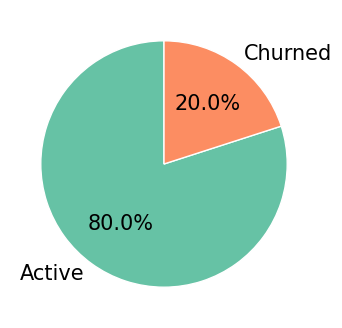

In [30]:
#pie chart
st.subheader("Customer Churn Distribution")
churn_counts=filtered_df["Exited"].value_counts()
left,center,right=st.columns([1.5,2,1.5])
with center:
    fig, ax =plt.subplots(figsize=(5,4))
    colors=sns.color_palette("Set2")
    wedges,texts,autotexts=ax.pie(
        churn_counts,
        labels=["Active","Churned"],
        autopct=lambda p:f"{p:.1f}%",
        startangle=90,
        colors=colors,
        textprops={'fontsize':15} , #label size
        wedgeprops={"edgecolor":"white"}
    )

In [33]:
#percentages font size
for autotext in autotexts:
      autotext.set_fontsize(15)
      ax.set_title("Churn vs Active Customers",fontsize=15)
      st.pyplot(fig)

st.divider()

st.subheader(" Customer Churn Patterns by Geography and Product Usage")

col1, col2 = st.columns(2)

2026-09-20 02:07:23.517 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:23.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:23.585 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:23.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:23.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:23.651 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:23.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:23.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [34]:
# -------- Geography Churn --------

In [35]:
 with col1:
        geo_churn = filtered_df.groupby("Geography")["Exited"].mean() * 100

        fig2, ax2 = plt.subplots(figsize=(6,3))
        sns.barplot(
            x=geo_churn.index,
            y=geo_churn.values,
            palette="viridis",
            ax=ax2
        )

        ax2.set_title("Churn Rate by Geography", fontsize=10)
        ax2.set_ylabel("%")
        ax2.tick_params(labelsize=8)

        st.pyplot(fig2)

/tmp/ipykernel_1508/3838366717.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
2026-09-20 02:07:49.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:49.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:49.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:07:49.601 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [36]:
# -------- Product Churn --------

In [37]:
 with col2:
        product_churn = filtered_df.groupby("NumOfProducts")["Exited"].mean() * 100

        fig3, ax3 = plt.subplots(figsize=(6,3))
        sns.barplot(
            x=product_churn.index,
            y=product_churn.values,
            palette="coolwarm",
            ax=ax3
        )

        ax3.set_title("Churn by Products", fontsize=10)
        ax3.set_ylabel("%")
        ax3.tick_params(labelsize=8)

        st.pyplot(fig3)

/tmp/ipykernel_1508/2685961229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
2026-09-20 02:08:13.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:08:14.025 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:08:14.026 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:08:14.027 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [38]:
#KPI-2:Product Utilization Impact Analysis

In [40]:
if page == "📦 Product Analysis":
    st.header("📦 Product Utilization Impact Analysis")

# Churn by number of products
st.subheader("Churn Rate by Number of Products")

2026-09-20 02:10:24.506 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:10:24.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:10:24.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [42]:
churn_by_products = (
        filtered_df.groupby("NumOfProducts")["Exited"].mean().reset_index()
    )

left1,center1,right1=st.columns([1,2,1])
with center1:

        fig1, ax1 = plt.subplots(figsize=(6,3))

        sns.barplot(
            data=churn_by_products,
            x="NumOfProducts",
            y="Exited",
            palette="Blues"
        )

        ax1.set_ylabel("Churn Rate")
        ax1.set_xlabel("Number of Products")
        ax1.set_title("Product Usage vs Churn")

        st.pyplot(fig1)

2026-09-20 02:11:23.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:11:23.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:11:23.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:11:23.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
/tmp/ipykernel_1508/339835444.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
2026-09-20 02:11:23.999 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:11:24.124 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-2

In [43]:
st.divider()

2026-09-20 02:11:34.847 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:11:34.848 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:11:34.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [45]:
 avg_balance = (
        filtered_df.groupby("NumOfProducts")["Balance"].mean().reset_index()
        )

st.subheader("Average Balance by Product Count")

2026-09-20 02:12:03.299 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:12:03.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:12:03.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [46]:
left2,center2,right2=st.columns([1,2,1])

2026-09-20 02:12:13.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:12:13.949 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:12:13.953 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:12:13.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [47]:
with center2:

        fig2, ax2 = plt.subplots(figsize=(6,3))

        sns.barplot(
            data=avg_balance,
            x="NumOfProducts",
            y="Balance",
            palette="Greens",
        )


/tmp/ipykernel_1508/1850132989.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


In [49]:
ax2.set_title("Balance Distribution by Product Count",fontsize=10)
ax2.set_ylabel("Churn Rate")
ax2.set_xlabel("Num of Products")
ax2.tick_params(labelsize=8)

st.pyplot(fig2)


2026-09-20 02:12:58.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:12:59.061 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:12:59.061 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:12:59.063 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [50]:
#KPI-3: High-value Disengaged Customer Detector

In [51]:
if page == "💰 High Value Risk":

    st.header(" High-Value Disengaged Customers")

In [52]:
# Define threshold
balance_threshold = st.slider("Select Minimum Balance", 0, 300000, 100000)

# High value customers
high_value = filtered_df[filtered_df["Balance"] > balance_threshold]


2026-09-20 02:14:02.889 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:02.890 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:02.892 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:02.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:02.894 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [54]:
# Among them, churned customers
high_risk = high_value[high_value["Exited"] == 1]

total_high_value = len(high_value)
total_high_risk = len(high_risk)
risk_percentage=(total_high_risk/total_high_value)*100 if total_high_value >0 else 0
col1, col2,col3 = st.columns(3)

col1.metric("💰 High Value Customers", total_high_value)
col2.metric("⚠ High Value At Risk", total_high_risk)
col3.metric("📊 Risk Percentage",f"{risk_percentage:.1f}%")


2026-09-20 02:14:50.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:50.432 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:50.434 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:50.435 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:50.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:50.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:50.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:14:50.439 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [55]:
st.markdown("---")

2026-09-20 02:15:01.488 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:15:01.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:15:01.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [58]:
if total_high_risk > 0:
        st.error("🔴 These premium customers are at churn risk!")
        st.dataframe(high_risk.head(20))
else:
        st.success("🟢 No high-value churn risk detected.")


2026-09-20 02:15:30.197 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:15:30.198 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:15:30.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:15:30.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:15:30.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:15:30.239 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:15:30.240 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [59]:
#KPI-4:Retention Strength Scoring Panel

In [60]:
if page == "📈 Retention Score":

    st.header("📈 Retention Strength Scoring Panel")

In [61]:
# ---- Create Retention Score ----

In [62]:
filtered_df["RetentionScore"] = (
        filtered_df["IsActiveMember"] * 30 +
        filtered_df["NumOfProducts"] * 20 +
        filtered_df["HasCrCard"] * 10 +
        filtered_df["Tenure"] * 2
    )

In [64]:
  # Scale to 0-100
filtered_df["RetentionScore"] = (filtered_df["RetentionScore"] / filtered_df["RetentionScore"].max()) * 100

avg_score = filtered_df["RetentionScore"].mean()
high_retention = len(filtered_df[filtered_df["RetentionScore"] > 60])
low_retention = len(filtered_df[filtered_df["RetentionScore"] < 30])

In [65]:
  # ---- KPI Cards ----
col1, col2, col3 = st.columns(3)

col1.metric("⭐ Average Retention Score", f"{avg_score:.2f}")
col2.metric("💚 High Retention Customers", high_retention)
col3.metric("🔴 Low Retention Customers", low_retention)

st.markdown("---")


2026-09-20 02:18:21.334 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:18:21.335 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:18:21.336 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:18:21.336 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:18:21.338 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:18:21.339 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:18:21.341 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:18:21.343 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [66]:
# ---- Color Based Status ----
if avg_score > 70:
        st.success("🟢 Strong Customer Loyalty Overall")
elif avg_score > 40:
        st.warning("🟡 Moderate Retention Strength")
else:
        st.error("🔴 Weak Retention – Attention Needed")

2026-09-20 02:21:34.033 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:21:34.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:21:34.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [67]:
 st.markdown("---")

2026-09-20 02:21:49.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:21:49.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:21:49.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [68]:
  # ---- Histogram Chart ----
st.subheader("📊 Retention Score Distribution")

2026-09-20 02:22:03.487 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:22:03.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:22:03.502 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [69]:
fig, ax = plt.subplots(figsize=(3.5,2.5))

In [70]:
sns.set_style("whitegrid")

In [71]:
sns.histplot(
        data=filtered_df,
        x="RetentionScore",
        hue="Exited",
        bins=15,
        kde=True,
        palette=["#4CAF50","#E53935"],
        alpha=0.6,
        multiple="layer",
        edgecolor="white",
        ax=ax
    )

<Axes: xlabel='RetentionScore', ylabel='Count'>

In [72]:
ax.legend_.remove()

In [73]:
#add custom legend
from matplotlib.patches import Patch
legend_elements=[Patch(facecolor="#4CAF50",label="Retained"),
                     Patch(facecolor="#E53935",label="Churned")
                     ]

In [74]:
ax.legend(
        handles=legend_elements,
        fontsize=7,
        loc="upper right"
    )

In [75]:
ax.set_xlabel("Retention Score",fontsize=8)
ax.set_ylabel("Number of Customers",fontsize=8)
ax.tick_params(labelsize=7)


left,center,right=st.columns([1,2,1])
with center:
    st.pyplot(fig)


2026-09-20 02:24:03.272 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:24:03.273 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:24:03.275 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:24:03.277 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:24:03.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:24:03.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:24:03.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:24:03.402 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [76]:
## Model insights heatmap
if page == "🧠 Model Insights":

  st.header("🧠 Model Performance & Feature Importance")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
 # -------- Prepare Data --------

In [78]:
X = pd.get_dummies(df.drop("Exited", axis=1), drop_first=True)

X = X[[
        "CreditScore", "Age", "Tenure", "Balance",
        "NumOfProducts", "HasCrCard", "IsActiveMember",
        "EstimatedSalary", "Geography_Germany",
        "Geography_Spain", "Gender_Male"
    ]]

y = df["Exited"]

In [79]:
 # -------- Train-Test Split (IMPORTANT for correct accuracy) --------

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

In [81]:
 # -------- Model Prediction --------

In [83]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

st.metric("🎯 Model Accuracy (Test Data)", f"{accuracy*100:.2f}%")

st.markdown("---")


2026-09-20 02:26:31.621 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:26:31.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:26:31.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:26:31.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:26:31.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:26:31.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [84]:
# -------- Confusion Matrix --------

In [85]:
st.subheader("Confusion Matrix")

cm = confusion_matrix(y_test, y_pred)

2026-09-20 02:26:54.620 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:26:54.621 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:26:54.622 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [86]:
 #create small centered layout
left,center,right=st.columns([1,2,1])

with center:

    fig_cm, ax_cm = plt.subplots(figsize=(4,3))
sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax_cm,
            annot_kws={"fontsize":8})

ax_cm.set_xlabel("Predicted",fontsize=9)
ax_cm.set_ylabel("Actual",fontsize=9)
ax_cm.set_title("Confusion Matrix",fontsize=8)
ax_cm.tick_params(labelsize=7)
plt.tight_layout()

st.pyplot(fig_cm)

st.markdown("---")


2026-09-20 02:28:22.769 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:22.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:22.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:22.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:22.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:23.162 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:23.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:23.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [87]:
# -------- Feature Importance --------
st.subheader("Top Features Driving Churn")

2026-09-20 02:28:38.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:38.522 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:28:38.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [88]:
#sort importance
importance = model.feature_importances_

feature_names = [
        "CreditScore", "Age", "Tenure", "Balance",
        "NumOfProducts", "HasCrCard", "IsActiveMember",
        "EstimatedSalary", "Geography_Germany",
        "Geography_Spain", "Gender_Male"
    ]
importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

In [90]:
#center layout
left,center,right=st.columns([1,2,1])

with center:
    fig_imp, ax_imp = plt.subplots(figsize=(5,4))

sns.barplot(
            x="Importance",
            y="Feature",
            data=importance_df,
            palette="viridis"
        )
ax_imp.set_title("Feature Importance (XGBoost)",fontsize=9)
ax_imp.tick_params(labelsize=8)
plt.tight_layout()
st.pyplot(fig_imp)

st.markdown("---")

2026-09-20 02:30:01.601 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:01.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:01.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:01.611 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
/tmp/ipykernel_1508/3092386591.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
2026-09-20 02:30:01.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:02.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-2

DeltaGenerator()

In [91]:
st.dataframe(importance_df, use_container_width=True)

st.markdown("---")

2026-09-20 02:30:36.881 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-20 02:30:36.899 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:36.906 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:36.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:36.914 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:36.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:30:36.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [92]:
st.subheader("🔍 Key Insights from Customer Data")
st.success("""
    - Customers with higher balances but inactive accounts show increased churn probability.
    - Customers owning only one banking product are more likely to churn.
    - Active members demonstrate significantly better retention rates.
    - Customer age and account balance strongly influence churn behavior.
    """)
st.markdown("---")

2026-09-20 02:31:27.123 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:27.126 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:27.129 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:27.134 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:27.136 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:27.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:27.141 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:27.145 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [93]:
st.subheader("📢 Business Recommendations")
st.info("""
    •  Implement targeted retention campaigns for high-value inactive customers.

    •  Encourage cross-selling of banking products to improve customer engagement.

    •  Strengthen loyalty programs for long-term customers.

    •  Provide personalized financial offers based on customer profile and behavior.
    """)


2026-09-20 02:31:46.212 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:46.213 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:46.216 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:46.218 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:46.219 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:31:46.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [96]:
#adding user inputs
if page == "🤖 Churn Prediction":
    st.header("Enter Customer Details")

    credit_score = st.number_input("Credit Score", 300, 900, 650)
    age = st.number_input("Age", 18, 100, 35)
    tenure = st.number_input("Tenure (Years)", 0, 20, 5)
    balance = st.number_input("Balance", 0.0, 300000.0, 50000.0)
    num_products = st.selectbox("Number of Products", [1,2,3,4])
    has_card = st.selectbox("Has Credit Card", [0,1])
    is_active = st.selectbox("Is Active Member", [0,1])
    salary = st.number_input("Estimated Salary", 0.0, 200000.0, 50000.0)

    geography = st.selectbox("Geography", ["France", "Germany", "Spain"])
    gender = st.selectbox("Gender", ["Female", "Male"])

In [98]:
if page == "🤖 Churn Prediction":
    #converting categorical to model format

    geo_germany = 1 if geography == "Germany" else 0
    geo_spain = 1 if geography == "Spain" else 0
    gender_male = 1 if gender == "Male" else 0

In [112]:
 if st.button("Predict Churn"):

        input_df=pd.DataFrame({
                           "CreditScore":[credit_score],
                           "Age":[age],
                           "Tenure":[tenure],
                           "Balance":[balance],
                           "NumOfProducts":[num_products],
                           "HasCrCard":[has_card],
                           "IsActiveMember":[is_active],
                           "EstimatedSalary":[salary],
                           "Geography_Germany":[geo_germany],
                           "Geography_Spain":[geo_spain],
                           "Gender_Male":[gender_male]
                           })
        prediction = model.predict(input_df)
        probability = model.predict_proba(input_df)[0][1]

        st.subheader("Prediction Result")
        st.metric(label="Churn Probability",
                          value=f"{probability*100:.2f}%",
                          delta=f"{(probability-0.5)*100:.2f}% vs baseline"
                          )

        if probability >= 0.7:
                st.error("🔴 High Risk of Churn")
        elif probability >= 0.4:
                st.warning("🟠 Medium Risk of Churn")
        else:
                st.success("🟢 Low Risk of Churn")

2026-09-20 02:39:03.322 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:39:03.324 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:39:03.326 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:39:03.328 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:39:03.329 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [113]:
st.markdown("---")

2026-09-20 02:39:30.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:39:30.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:39:30.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [114]:
st.caption("Developed by Deepa Puhan Bhujbal")

2026-09-20 02:39:51.811 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:39:51.814 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 02:39:51.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()